In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Load Dengue data

In [5]:
# The previous run resulted in a FileNotFoundError because the specified file path was incorrect.
# Please update the 'file_path' variable below with the correct path to your CSV file.
# You can verify the file path by navigating to the file in Google Drive, right-clicking on it,
# and selecting 'Copy path'.
file_path = "/content/drive/MyDrive/Dengue_Prophet_Cleaned.csv"  # <--- Please update this path!

dengue = pd.read_csv(
    file_path
)

dengue["ds"] = pd.to_datetime(dengue["ds"])

dengue["y"] = pd.to_numeric(
    dengue["y"],
    errors="coerce"
)

dengue = (
    dengue
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .reset_index(drop=True)
)

print("Dengue rows:", len(dengue))
print("Start:", dengue["ds"].min())
print("End:", dengue["ds"].max())

dengue.head()

Dengue rows: 37
Start: 2023-06-01 00:00:00
End: 2026-06-01 00:00:00


,ds,y
0,2023-06-01,528
1,2023-07-01,960
2,2023-08-01,602
3,2023-09-01,953
4,2023-10-01,1658


Calculate Dengue Z-score

In [6]:
dengue_mean = dengue["y"].mean()
dengue_std = dengue["y"].std()

print("Dengue mean:", dengue_mean)
print("Dengue standard deviation:", dengue_std)

Dengue mean: 2684.6216216216217
Dengue standard deviation: 3276.167275875809


In [7]:
dengue["z_score"] = (
    (dengue["y"] - dengue_mean)
    / dengue_std
)

In [8]:
dengue[
    ["ds", "y", "z_score"]
].tail(12)

,ds,y,z_score
25,2025-07-01,1029,-0.505353
26,2025-08-01,1015,-0.509626
27,2025-09-01,3275,0.180204
28,2025-10-01,7780,1.555286
29,2025-11-01,5115,0.741836
30,2025-12-01,884,-0.549612
31,2026-01-01,1218,-0.447664
32,2026-02-01,304,-0.726648
33,2026-03-01,283,-0.733058
34,2026-04-01,1618,-0.325570


5. Classify Dengue anomalies

In [9]:
def classify_zscore(z):

    if z >= 3:
        return "Critical"

    elif z >= 2:
        return "Alert"

    else:
        return "Normal"

In [10]:
dengue["anomaly_level"] = (
    dengue["z_score"]
    .apply(classify_zscore)
)

In [11]:
print(
    dengue[
        ["ds", "y", "z_score", "anomaly_level"]
    ].tail(15)
)

           ds     y   z_score anomaly_level
22 2025-04-01   431 -0.687884        Normal
23 2025-05-01   499 -0.667128        Normal
24 2025-06-01   598 -0.636909        Normal
25 2025-07-01  1029 -0.505353        Normal
26 2025-08-01  1015 -0.509626        Normal
27 2025-09-01  3275  0.180204        Normal
28 2025-10-01  7780  1.555286        Normal
29 2025-11-01  5115  0.741836        Normal
30 2025-12-01   884 -0.549612        Normal
31 2026-01-01  1218 -0.447664        Normal
32 2026-02-01   304 -0.726648        Normal
33 2026-03-01   283 -0.733058        Normal
34 2026-04-01  1618 -0.325570        Normal
35 2026-05-01  1949 -0.224537        Normal
36 2026-06-01  1171 -0.462010        Normal


Add anomaly flag

In [12]:
dengue["is_anomaly"] = (
    dengue["z_score"] >= 2
)

Visualize Dengue anomalies

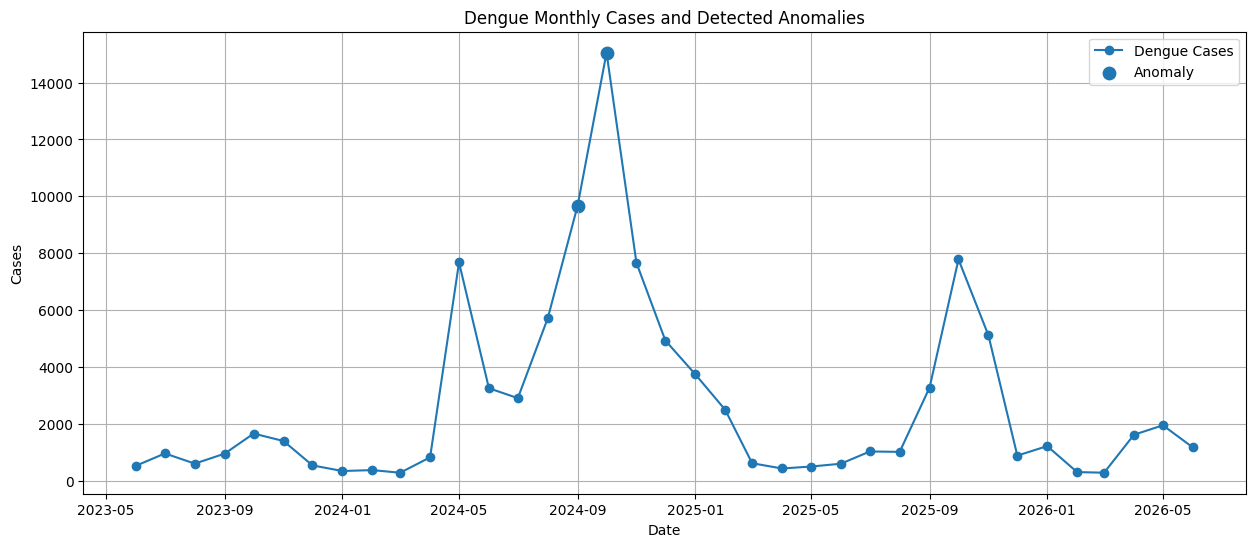

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(
    dengue["ds"],
    dengue["y"],
    marker="o",
    label="Dengue Cases"
)

anomalies = dengue[
    dengue["is_anomaly"]
]

plt.scatter(
    anomalies["ds"],
    anomalies["y"],
    s=80,
    label="Anomaly"
)

plt.title("Dengue Monthly Cases and Detected Anomalies")

plt.xlabel("Date")
plt.ylabel("Cases")

plt.legend()
plt.grid(True)

plt.show()

Plot the Z-score itself

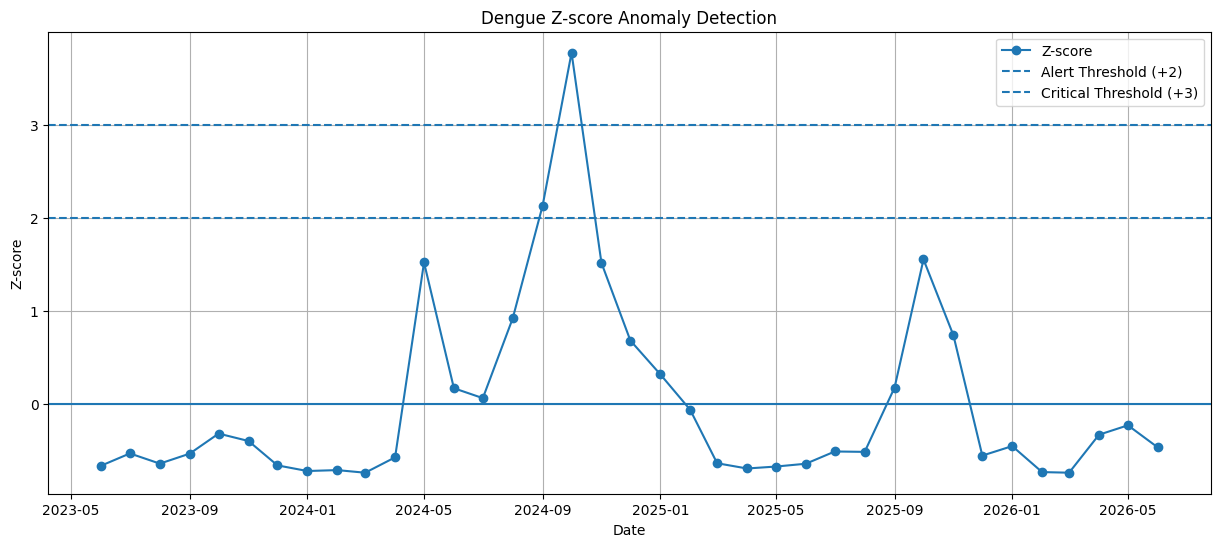

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(
    dengue["ds"],
    dengue["z_score"],
    marker="o",
    label="Z-score"
)

plt.axhline(
    2,
    linestyle="--",
    label="Alert Threshold (+2)"
)

plt.axhline(
    3,
    linestyle="--",
    label="Critical Threshold (+3)"
)

plt.axhline(
    0,
    linestyle="-"
)

plt.title("Dengue Z-score Anomaly Detection")

plt.xlabel("Date")
plt.ylabel("Z-score")

plt.legend()
plt.grid(True)

plt.show()

Now do Typhoid

In [22]:
# The previous run resulted in a FileNotFoundError because the specified file path was incorrect.
# Please update the 'file_path_typhoid' variable below with the correct path to your CSV file.
# You can verify the file path by navigating to the file in Google Drive, right-clicking on it,
# and selecting 'Copy path'.
file_path_typhoid = "/content/drive/MyDrive/Typhoid_Surveillance_Clean.csv"  # <--- Please update this path!

typhoid = pd.read_csv(
    file_path_typhoid
)

print("Dataset shape:", typhoid.shape)

typhoid.head()

Dataset shape: (39834, 10)


,Patient_ID,Screening_Date,Enrollment_Date,Site,Province,City,Location,Case_Status,Blood_Culture_Result,TCV_Status
0,PK-SIH-00001,2020-10-05,2020-10-06,SIH,Federal,Islamabad,OPD,Suspected,NBG,Unknown
1,PK-SIH-00002,2020-10-06,2020-10-06,SIH,Federal,Islamabad,OPD,Suspected,ST,No
2,PK-SIH-00003,2020-10-06,2020-10-06,SIH,Federal,Islamabad,Inpatient,Confirmed,NBG,No
3,PK-NICH-00001,2020-10-06,2020-10-09,NICH,Sindh,Karachi,OPD,Suspected,NBG,No
4,PK-NICH-00002,2020-10-06,2020-10-09,NICH,Sindh,Karachi,OPD,Confirmed,NBG,Unknown


Convert date

In [23]:
typhoid["Screening_Date"] = pd.to_datetime(
    typhoid["Screening_Date"],
    errors="coerce"
)

typhoid = typhoid.dropna(
    subset=["Screening_Date"]
)

Select confirmed cases

In [24]:
confirmed_typhoid = typhoid[
    typhoid["Case_Status"]
    .str.lower()
    .eq("confirmed")
].copy()

print(
    "Total confirmed cases:",
    len(confirmed_typhoid)
)

Total confirmed cases: 2720


Convert Typhoid to monthly cases

In [25]:
typhoid_monthly = (
    confirmed_typhoid
    .set_index("Screening_Date")
    .resample("MS")
    .size()
    .reset_index(name="Cases")
)

In [26]:
typhoid_monthly = typhoid_monthly.rename(
    columns={
        "Screening_Date": "ds",
        "Cases": "y"
    }
)

In [27]:
print(
    typhoid_monthly.head()
)

print(
    "Months:",
    len(typhoid_monthly)
)

          ds   y
0 2020-10-01   6
1 2020-11-01  13
2 2020-12-01  17
3 2021-01-01  27
4 2021-02-01  39
Months: 58


Calculate Typhoid Z-score

In [28]:
typhoid_mean = typhoid_monthly["y"].mean()

typhoid_std = typhoid_monthly["y"].std()

print("Typhoid mean:", typhoid_mean)
print("Typhoid standard deviation:", typhoid_std)

Typhoid mean: 46.89655172413793
Typhoid standard deviation: 19.802259002068347


In [29]:
typhoid_monthly["z_score"] = (
    (
        typhoid_monthly["y"]
        - typhoid_mean
    )
    / typhoid_std
)

Classify Typhoid anomalies

In [30]:
typhoid_monthly["anomaly_level"] = (
    typhoid_monthly["z_score"]
    .apply(classify_zscore)
)

In [31]:
typhoid_monthly["is_anomaly"] = (
    typhoid_monthly["z_score"] >= 2
)

In [32]:
print(
    typhoid_monthly[
        [
            "ds",
            "y",
            "z_score",
            "is_anomaly",
            "anomaly_level"
        ]
    ].tail(15)
)

           ds   y   z_score  is_anomaly anomaly_level
43 2024-05-01  76  1.469703       False        Normal
44 2024-06-01  58  0.560716       False        Normal
45 2024-07-01  47  0.005224       False        Normal
46 2024-08-01  45 -0.095775       False        Normal
47 2024-09-01  42 -0.247272       False        Normal
48 2024-10-01  42 -0.247272       False        Normal
49 2024-11-01  32 -0.752265       False        Normal
50 2024-12-01  23 -1.206759       False        Normal
51 2025-01-01  37 -0.499769       False        Normal
52 2025-02-01  29 -0.903763       False        Normal
53 2025-03-01  37 -0.499769       False        Normal
54 2025-04-01  29 -0.903763       False        Normal
55 2025-05-01  39 -0.398770       False        Normal
56 2025-06-01  32 -0.752265       False        Normal
57 2025-07-01  25 -1.105760       False        Normal


Plot Typhoid anomalies

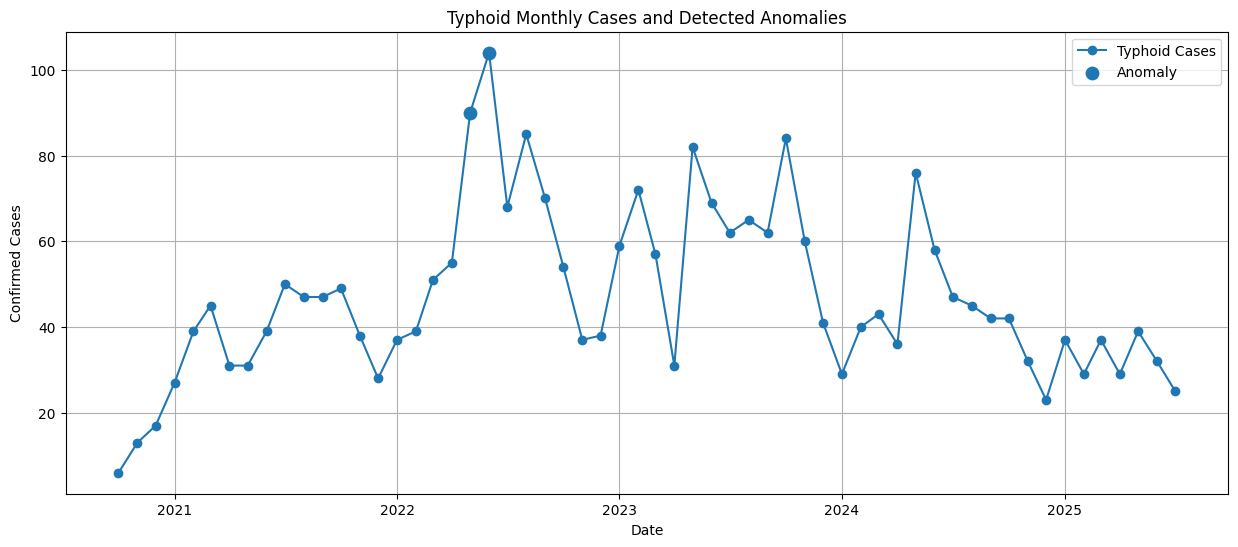

In [33]:
plt.figure(figsize=(15, 6))

plt.plot(
    typhoid_monthly["ds"],
    typhoid_monthly["y"],
    marker="o",
    label="Typhoid Cases"
)

anomalies = typhoid_monthly[
    typhoid_monthly["is_anomaly"]
]

plt.scatter(
    anomalies["ds"],
    anomalies["y"],
    s=80,
    label="Anomaly"
)

plt.title(
    "Typhoid Monthly Cases and Detected Anomalies"
)

plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.legend()
plt.grid(True)

plt.show()

Plot Typhoid Z-scores

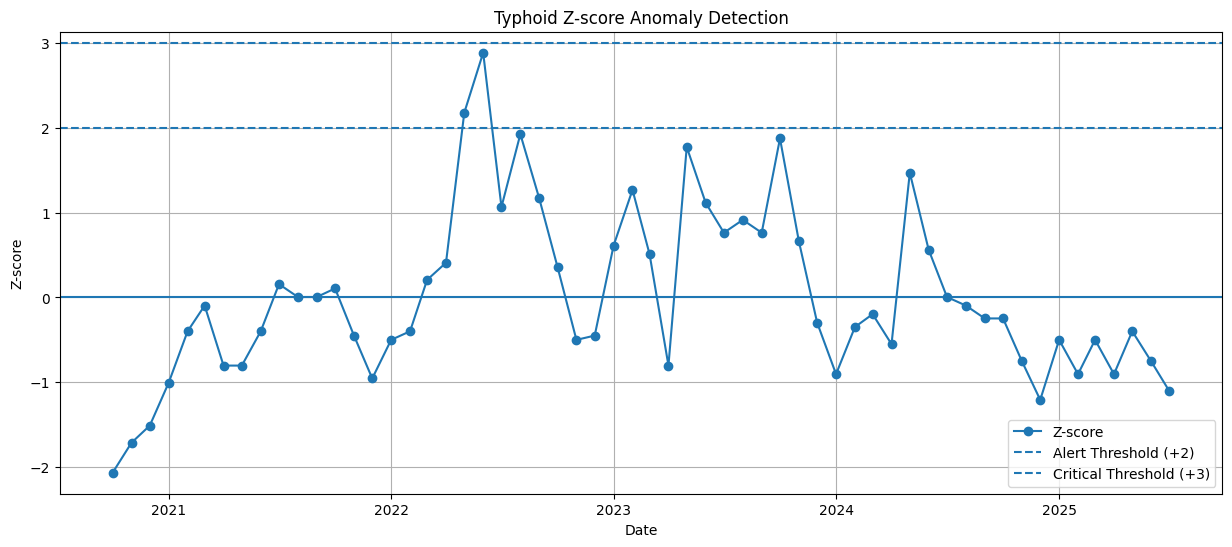

In [34]:
plt.figure(figsize=(15, 6))

plt.plot(
    typhoid_monthly["ds"],
    typhoid_monthly["z_score"],
    marker="o",
    label="Z-score"
)

plt.axhline(
    2,
    linestyle="--",
    label="Alert Threshold (+2)"
)

plt.axhline(
    3,
    linestyle="--",
    label="Critical Threshold (+3)"
)

plt.axhline(
    0,
    linestyle="-"
)

plt.title(
    "Typhoid Z-score Anomaly Detection"
)

plt.xlabel("Date")
plt.ylabel("Z-score")

plt.legend()
plt.grid(True)

plt.show()

**Create a clean anomaly table**

Dengue

In [35]:
dengue_anomaly_results = dengue[
    [
        "ds",
        "y",
        "z_score",
        "is_anomaly",
        "anomaly_level"
    ]
].copy()

dengue_anomaly_results["disease"] = "Dengue"

dengue_anomaly_results = dengue_anomaly_results[
    [
        "disease",
        "ds",
        "y",
        "z_score",
        "is_anomaly",
        "anomaly_level"
    ]
]

Typhoid

In [36]:
typhoid_anomaly_results = typhoid_monthly[
    [
        "ds",
        "y",
        "z_score",
        "is_anomaly",
        "anomaly_level"
    ]
].copy()

typhoid_anomaly_results["disease"] = "Typhoid"

typhoid_anomaly_results = typhoid_anomaly_results[
    [
        "disease",
        "ds",
        "y",
        "z_score",
        "is_anomaly",
        "anomaly_level"
    ]
]

Combine both diseases

In [37]:
all_anomalies = pd.concat(
    [
        dengue_anomaly_results,
        typhoid_anomaly_results
    ],
    ignore_index=True
)

all_anomalies = all_anomalies.sort_values(
    ["ds", "disease"]
)

all_anomalies.head(20)

,disease,ds,y,z_score,is_anomaly,anomaly_level
37,Typhoid,2020-10-01,6,-2.065247,False,Normal
38,Typhoid,2020-11-01,13,-1.711752,False,Normal
39,Typhoid,2020-12-01,17,-1.509755,False,Normal
40,Typhoid,2021-01-01,27,-1.004762,False,Normal
41,Typhoid,2021-02-01,39,-0.398770,False,Normal
42,Typhoid,2021-03-01,45,-0.095775,False,Normal
43,Typhoid,2021-04-01,31,-0.802765,False,Normal
44,Typhoid,2021-05-01,31,-0.802765,False,Normal
45,Typhoid,2021-06-01,39,-0.398770,False,Normal
46,Typhoid,2021-07-01,50,0.156722,False,Normal


Show only detected anomalies

In [38]:
detected_anomalies = all_anomalies[
    all_anomalies["is_anomaly"]
].copy()

print(
    "Total anomalies detected:",
    len(detected_anomalies)
)

detected_anomalies

Total anomalies detected: 4


,disease,ds,y,z_score,is_anomaly,anomaly_level
56,Typhoid,2022-05-01,90,2.176693,True,Alert
57,Typhoid,2022-06-01,104,2.883684,True,Alert
15,Dengue,2024-09-01,9671,2.132485,True,Alert
16,Dengue,2024-10-01,15047,3.773427,True,Critical


In [39]:
print(
    detected_anomalies[
        [
            "disease",
            "ds",
            "y",
            "z_score",
            "anomaly_level"
        ]
    ]
)

    disease         ds      y   z_score anomaly_level
56  Typhoid 2022-05-01     90  2.176693         Alert
57  Typhoid 2022-06-01    104  2.883684         Alert
15   Dengue 2024-09-01   9671  2.132485         Alert
16   Dengue 2024-10-01  15047  3.773427      Critical


Save the results

In [41]:
all_anomalies.to_csv(
    "/content/drive/MyDrive/all_disease_zscore_results.csv",
    index=False
)

print(
    "Z-score anomaly results saved successfully."
)

Z-score anomaly results saved successfully.
